<a href="https://colab.research.google.com/github/nmhom/MAT-422/blob/main/MAT422_HW_3.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.4 Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Logistic Regression:
A supervised learning method used to predict the probability that an observation belongs to one of two classes.

For input features $\alpha \in \mathbb{R}^d$, logistic regression models the probability of class 1 as

$$p(\alpha;x) = \sigma(\alpha^T x),$$

where $x$ is the vector of model parameters and $\sigma$ is the sigmoid function: $$\sigma(t) = \frac{1}{e^{-t}}.$$

It maps any real number to a value between 0 and 1, allowing its output to represent a probability.

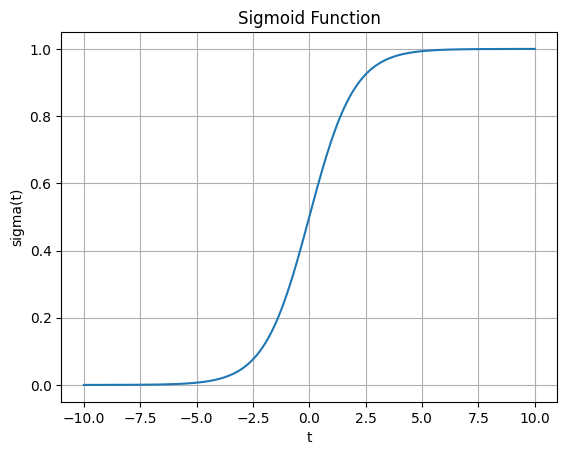

In [4]:
def sigmoid(t):
  return 1 / (1 + np.exp(-t))

t = np.linspace(-10, 10, 200)

plt.plot(t, sigmoid(t))
plt.xlabel('t')
plt.ylabel('sigma(t)')
plt.title("Sigmoid Function")
plt.grid()
plt.show()

### Gradient of the Cross-Entropy Loss

For logistic regression, the gradient of the cross-entropy loss is

$$\nabla\phi(x) = -\frac{1}{n} \sum_{i=1}^{n} (b_i-\sigma(\alpha_i^T x))\alpha_i.$$

The gradient gives the direction in which the loss increases most rapidly. Gradient descent therefore moves in the opposite direction to reduce the loss.

In [5]:
hours = np.array([1,2,3,4,5,6,7,8], dtype=float)
b = np.array([0,0,0,0,1,1,1,1], dtype=float)

# intercept
A = np.column_stack((np.ones(len(hours)), hours))

# starting parameters
x = np.zeros(2)

beta = 0.1
losses = []

for _ in range(1000):
  probabilities = sigmoid(A @ x)

  loss = -np.mean(
      b * np.log(probabilities + 1e-10)
      + (1 - b) * np.log(1 -probabilities + 1e-10)
  )
  losses.append(loss)

  gradient = -(1 / len(b)) * A.T @ (b-probabilities)
  x = x - beta * gradient

print("Learned parameters:", x)

Learned parameters: [-5.67648623  1.32236696]


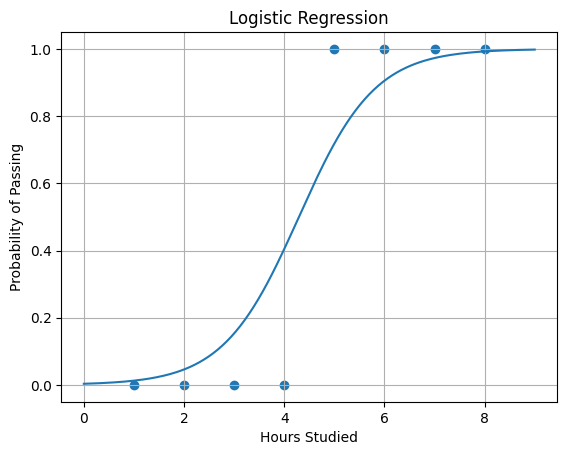

In [6]:
hours_plot = np.linspace(0, 9, 200)

A_plot = np.column_stack((
    np.ones(len(hours_plot)),
    hours_plot
))

probability = sigmoid(A_plot @ x)

plt.scatter(hours, b)
plt.plot(hours_plot, probability)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression")
plt.grid()
plt.show()

### Note on Convexity

The Hessian of the cross-entropy loss is positive semidefinite, which means the loss function is convex. Therefore, logistic regression has a well-behaved optimization problem, and gradient descent can be used to minimize the loss.